In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, GRU
import xgboost as xgb
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
base_dir = Path(r'E:\NYISO_Project\dataset')

In [3]:
X_train = np.load(base_dir / 'X_train.npy')
y_train = np.load(base_dir / 'y_train.npy')
X_val = np.load(base_dir / 'X_val.npy')
y_val = np.load(base_dir / 'y_val.npy')

In [4]:
print(f"X_train shape: {X_train.shape}")

X_train shape: (52579, 24, 1)


In [28]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

##### LSTM Model

In [29]:
# LSTM model
model_lstm = Sequential()
model_lstm.add(Input(shape=(X_train.shape[1], 1)))
model_lstm.add(LSTM(64, return_sequences=True))
model_lstm.add(Dropout(0.2))  # Add dropout to prevent overfitting
model_lstm.add(LSTM(64))
model_lstm.add(Dropout(0.2))  # Add dropout to prevent overfitting
model_lstm.add(Dense(32, activation='relu'))  # Add a dense layer for better learning
model_lstm.add(Dense(1))  # Output layer for regression
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

In [31]:
# LSTM Model training
history_lstm = model_lstm.fit(X_train, y_train, epochs=50, batch_size=128, 
                    validation_data=(X_val, y_val), callbacks=[early_stop], verbose=1)

Epoch 1/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 0.0332 - val_loss: 0.0172
Epoch 2/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0199 - val_loss: 0.0129
Epoch 3/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - loss: 0.0160 - val_loss: 0.0084
Epoch 4/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - loss: 0.0135 - val_loss: 0.0059
Epoch 5/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: 0.0116 - val_loss: 0.0050
Epoch 6/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0106 - val_loss: 0.0045
Epoch 7/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - loss: 0.0102 - val_loss: 0.0046
Epoch 8/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - loss: 0.0096 - val_loss: 0.0042
Epoch 9/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0092 - val_loss: 0.0044
Epoch 10/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.0087 - val_loss: 0.0040
Epoch 11/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 0.0085 - val_loss: 0.0043
Epoch 12/50
411/411 ━━━━━━━━━━━━

##### GRU Model

In [32]:
 # GRU model
model_gru = Sequential()
model_gru.add(Input(shape=(X_train.shape[1], 1)))
model_gru.add(GRU(64, return_sequences=True))
model_gru.add(Dropout(0.2))  # Add dropout to prevent overfitting
model_gru.add(GRU(64)) 
model_gru.add(Dropout(0.2))  # Add dropout to prevent overfitting
model_gru.add(Dense(32, activation='relu'))  # Add a dense layer for better learning
model_gru.add(Dense(1))  # Output layer for regression
model_gru.compile(optimizer='adam', loss='mean_squared_error')

In [33]:
# GRU model training
history_gru = model_gru.fit(X_train, y_train, epochs=50, batch_size=128,
                            validation_data=(X_val, y_val), callbacks=[early_stop], verbose=1)

Epoch 1/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - loss: 0.0594 - val_loss: 0.0110
Epoch 2/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0150 - val_loss: 0.0060
Epoch 3/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - loss: 0.0122 - val_loss: 0.0058
Epoch 4/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0110 - val_loss: 0.0054
Epoch 5/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - loss: 0.0102 - val_loss: 0.0053


##### Visualization

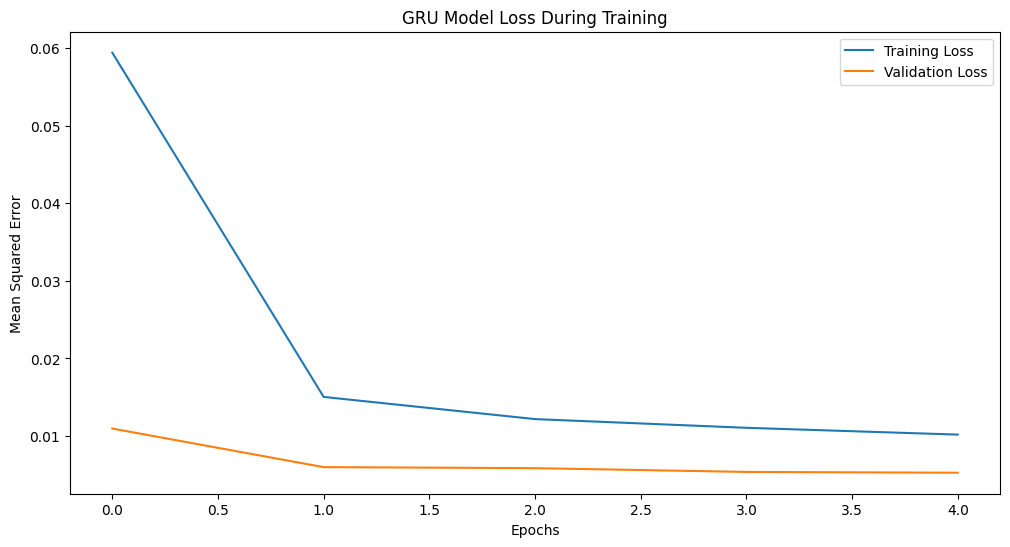

In [34]:
# Loss of the GRU model
plt.figure(figsize=(12, 6))
plt.plot(history_gru.history['loss'], label='Training Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.title('GRU Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()

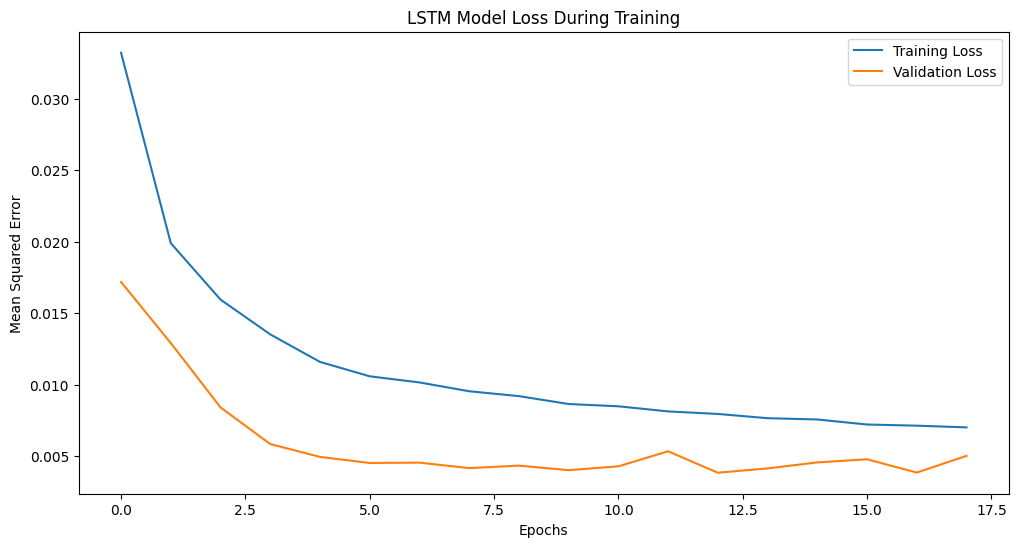

In [35]:
# Loss of the LSTM model
plt.figure(figsize=(12, 6))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()

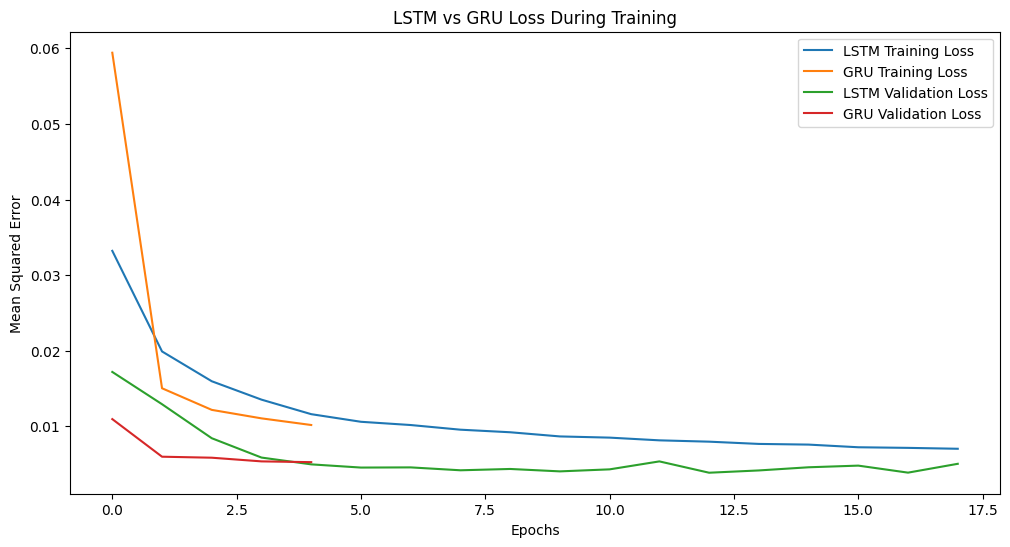

In [36]:
# LSTM and GRU on the same plot
plt.figure(figsize=(12, 6))
plt.plot(history_lstm.history['loss'], label='LSTM Training Loss')
plt.plot(history_gru.history['loss'], label='GRU Training Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Validation Loss')
plt.plot(history_gru.history['val_loss'], label='GRU Validation Loss')
plt.title('LSTM vs GRU Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()

In [37]:
# Saving the trained model for future use
model_lstm.save(r'E:\NYISO_Project\models\load_forecasting_lstm.keras')
model_gru.save(r'E:\NYISO_Project\models\load_forecasting_gru.keras')